# TAPIR

TAPIR o "Tracking Any Point with per-frame Initialization and temporal Refinement" de sus siglas en inglés es uno de los modelos más avanzados en la tarea de seguimiento de cualquier punto. Este tipo de tareas surgió con la creación de base de datos TAP-Vid, la cual se creo cómo respuesta a la falta de base de datos donde poder evaluar el seguimiento de puntos arbitrarios en los videos.

En este tutorial nos centraremos en realizar inferencia con este modelo. Dejamos de lado el entrenamiento debido a que es un proceso demorado, y que no nos aportará tanto en el aprendizaje. Sin embargo, si quiere profundizar en las características y funcionamiento del modelo o quisiera personalizarlo puede dirigirse al siguiente [enlace](https://github.com/google-deepmind/tapnet) que contiene el repositorio original del trabajo.

En más detalle en este tutorial nos centraremos en comprender dos modelos de TAPIR. El primero es un TAPIR offline, lo que quiere decir que el modelo realiza seguimiento para todo un video al mismo tiempo. El segundo modelo es un TAPIR online, lo que quiere decir que el modelo realiza seguimiento solo teniendo en cuenta los fotogramas anteriores y el actual.

La idea general detrás del modelo es la siguiente:
1. Dados unos puntos de consulta iniciales computamos un características de consulta para cada punto.
2. Ahora, por cada fotograma t calculamos el producto punto entre las características de consulta y todas las características en el fotograma t, para obtener un volumen de costos que mediante una red convolucional nos da una idea inicial de la trayectoria, oclusión e incertidumbre.
3. Finalmente, en la etapa de refinamiento se realiza un proceso iterativo donde se comparan las características de consulta con una región alrededor del punto. Luego, se ingresan las comparaciones a un red neuronal para actualizar las características de consulta y las trayectoria.

En la siguiente imagen podemos observar el proceso seguido por el modelo.

<div>
<p style = 'text-align:center;'>
<img src="modelo.png" width="500"/>
</p>
</div>

## Preparación

Primero, nos aseguraremos de importar todas las librerías necesarias. Además de las usuales importaremos la librería tapnet con la que podremos utilizar los modelos de TAPIR que utilizaremos en este tutorial.

In [1]:
%matplotlib ipympl
import matplotlib.pyplot as plt
import mediapy as media
import numpy as np
import os

import torch
import torch.nn.functional as F

from tapnet.torch import tapir_model
from tapnet.torch import utils
from tapnet.utils import transforms
from tapnet.utils import viz_utils

## Cargar video a procesar

Ahora, cargaremos y visualizaremos el video que utilizaremos para realizar el seguimiento. Además, revisaremos las dimensiones de este.

In [2]:
video = media.read_video('sample_videos/video_2.mp4')
media.show_video(video)

print(f"Las dimensiones de este video son: {video.shape} (fotogramas, Altura, Ancho, canales).")

This browser does not support the video tag.


Las dimensiones de este video son: (66, 480, 854, 3) (fotogramas, Altura, Ancho, canales).


Cómo podemos observar es un video bastante corto pero nos servirá para observar el seguimiento de puntos.

## Offline tracking: Cargar modelo

Dentro de la librería de tapnet hay un clase llamada `TAPIR`. Para la creación del modelo utilizaremos esta clase y definiremos un parámetro específico el cual es `pyramid_level` el cual hace referencia a cuántos niveles tendrá la pirámide que utilizaremos. En este caso construiremos el modelo con solo un nivel en la pirámide. Además, cargaremos los pesos que descargamos anteriormente.

In [3]:
model = tapir_model.TAPIR(pyramid_level=1)
model.load_state_dict(torch.load('checkpoints/bootstapir_checkpoint_v2.pt', weights_only=True))

# Enviamos el modelo a GPU si está disponible
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Utilizamos eval debido a que realizaremos inferencia
model = model.eval()

## Selección de puntos

Ahora, inicializaremos puntos manualmente para que el modelo pueda seguirlos. En este caso seleccionaremos el primer fotograma para seleccionar los puntos para iniciar el seguimiento. Para eso utilizaremos la librería de matplotlib para realizar la selección de puntos mediante un click en la imagen. Si la siguiente celda no funciona correctamente puede saltarla y utilizar unos puntos previamente seleccionados.

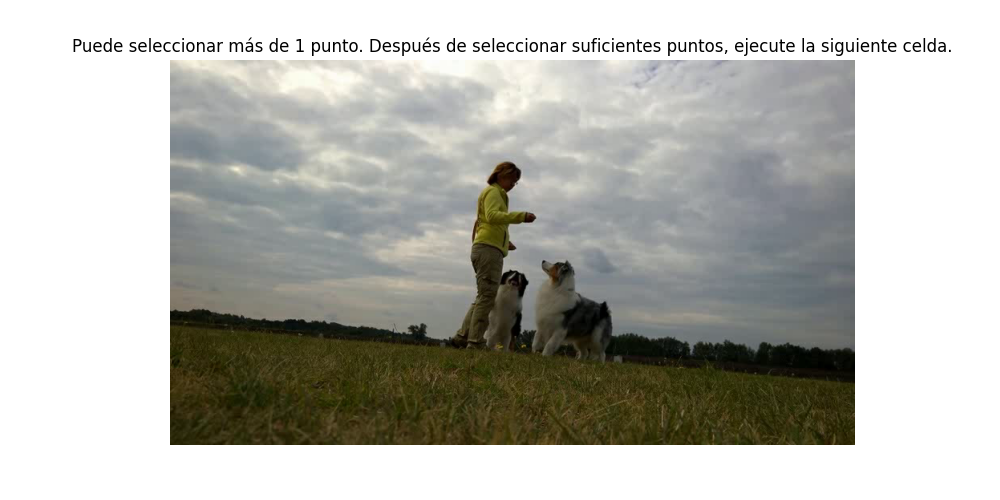

In [4]:
select_frame = 0

# Genera un mapa de color de 50 puntos, no es necesario cambiarlo a menos que tengamos más de 50 puntos a seguir
colormap = viz_utils.get_colors(50)

# Crea un subplot para la selección de puntos manualmente
fig, ax = plt.subplots(figsize=(10, 5))
ax.imshow(video[select_frame])
ax.axis('off')
ax.set_title('Puede seleccionar más de 1 punto. Después de seleccionar suficientes puntos, ejecute la siguiente celda.')

select_points = []

# Esta función se encargará de controlar los eventos para clicks de mouse
def on_click(event):
    if event.button == 1 and event.inaxes == ax:  # Click izquierdo

        # Se toma las coordenadas del click
        x, y = int(np.round(event.xdata)), int(np.round(event.ydata))

        # Se agregan a una lista
        select_points.append(np.array([x, y]))

        # Se utiliza un color dentro del mapa de color para dibujar los puntos
        color = colormap[len(select_points) - 1]
        color = tuple(np.array(color) / 255.0)
        ax.plot(x, y, 'o', color=color, markersize=5)
        plt.draw()

# Este método utiliza detecta los clicks y mediante la función on_click realiza la selección de los puntos
fig.canvas.mpl_connect('button_press_event', on_click)
plt.show()

## Procesamiento

Las siguientes funciones son usadas para el preprocesamiento de las entradas y salidas del modelo. `preprocess_frames()` es una función que preprocesa los fotogramas del video. Realiza una conversión de las intensidades del modelo, convirtiendolas desde el rango [0, 255] a [-1, 1]. Por otro lado, `post_process_occlusions` es una función que dada la probabilidad de oclusión e incertidumbre del punto, retorna la visibilidad del punto.

In [15]:
def preprocess_frames(frames):
    """Esta función preprocesa los fotogramas de entrada de tal manera sean compatibles con las entrada al modelo.

    Args:
    frames (torch.Tensor): [num_frames, height, width, 3], [0, 255], uint8

    Returns:
    frames (torch.Tensor): [num_frames, height, width, 3], [-1, 1], float32
    """
    frames = frames.float()
    frames = frames / 255 * 2 - 1
    return frames


def postprocess_occlusions(occlusions, expected_dist):
    """Esta función postprocesa la probabilidad de oclusión que arroja el modelo.

    Args:
      occlusions (torch.Tensor): Probabilidad de oclusión
      expected_dist (torch.Tensor): Logits de incertidumbre para el modelo

    Returns:
      (torch.Tensor): Determinar la visibilidad de los puntos de consulta
    """
    visibles = (1 - F.sigmoid(occlusions)) * (1 - F.sigmoid(expected_dist)) > 0.5
    return visibles

Antes de hacer la inferencia realizaremos un resize del video. De tal manera que el video tenga fotogramas cuadramos de esta manera:

In [16]:
# Altura y ancho, toda esta información es para mostrar correctamente el video
height, width = video.shape[1:3]

resize_height = 256
resize_width = 256

# Esta función realiza un cambio en el tamaño de los fotogramas del video
frames = media.resize_video(video, (resize_width, resize_height))
frames.shape

(66, 256, 256, 3)

Ahora convertiremos los puntos que seleccionamos antes a puntos de consulta. Para eso a cada una de los puntos le agregaremos un primer valor correspondiente a el frame seleccionado (en este caso 0). De esa manera cada uno de los puntos de consulta tendrán la siguiente forma (t, y, x) donde t es el frame donde se inicializan y (y, x) son las coordenadas espaciales.

In [17]:
print(f"Las dimensiones de los puntos seleccionados son los siguientes: {np.array(select_points).shape}")

# Agrega el frame que se utiliza para inicializar los puntos de consulta
points = np.stack(select_points)
query_points = np.zeros(shape=(points.shape[0], 3), dtype=np.float32)
query_points[:, 0] = select_frame
query_points[:, 1] = points[:, 1]
query_points[:, 2] = points[:, 0]

print(f"Las dimensiones de los puntos de consulta son los siguientes{query_points.shape}")

Las dimensiones de los puntos seleccionados son los siguientes: (2, 2)
Las dimensiones de los puntos de consulta son los siguientes(2, 3)


Ahora realizaremos una conversión en las coordenadas de todos los puntos de consulta. Eso quiere decir que vamos a realizar un transformación para que queden en nuestro nuevo sistema de coordenadas.

In [18]:
# Transforma los arreglos que contienen los puntos de consulta del sistema de coordenadas antiguo al nuevo
# height, width -> resize_width, resize_height

print(f"El primer punto de consulta tiene estas coordenadas antes de ser transformada: {list(query_points[1])}")

query_points = transforms.convert_grid_coordinates(
    query_points, (1, height, width), (1, resize_width, resize_height), coordinate_format='tyx')

print(f"El primer punto de consulta tiene estas coordenadas luego de ser transformada: {list(query_points[1])}")

El primer punto de consulta tiene estas coordenadas antes de ser transformada: [0.0, 291.0, 483.0]
El primer punto de consulta tiene estas coordenadas luego de ser transformada: [0.0, 155.2, 144.78688524590163]


Ahora realicemos los preprocesamientos necesarios con las funciones definidas anteriormente. Además, añadiremos un dimensión adicional a los tensores `frames` y `query_points` debido a que el modelo necesita recibir los videos por lotes o batches.

In [19]:
# Los arreglos se convierten en tensores y enviados a device
frames = torch.tensor(frames).to(device)
query_points = torch.tensor(query_points).to(device)

# Preprocesa los fotogramas para que estén en el formato adecuado
print(f"Valor máximo {frames.max()}, valor mínimo {frames.min()}")
frames = preprocess_frames(frames)
print(f"Valor máximo {frames.max()}, valor mínimo {frames.min()}")

# Convertir en flotantes
query_points = query_points.float()

# Agregar una dimensión en la videos. Simulando un lote de 1
print(f"Las dimesiones del tensor frames es {tuple(frames.size())}, Las dimensiones del tensor query_points es {tuple(query_points.size())}")
frames, query_points = frames[None], query_points[None]
print(f"Las dimesiones del tensor frames es {tuple(frames.size())}, Las dimensiones del tensor query_points es {tuple(query_points.size())}")

Valor máximo 255, valor mínimo 0
Valor máximo 1.0, valor mínimo -1.0
Las dimesiones del tensor frames es (66, 256, 256, 3), Las dimensiones del tensor query_points es (2, 3)
Las dimesiones del tensor frames es (1, 66, 256, 256, 3), Las dimensiones del tensor query_points es (1, 2, 3)


## Inferencia

Ahora vamos a utilizar el modelo para hacer inferencia. La salida del modelo es un diccionario cuyas más importantes llaves son:
- **tracks:** Hace referencia a las trayectorias que siguen cada uno de los puntos.
- **Occlusion:** Contiene la probabilidad de que el punto este ocluido en cada parte de la trayectoria.
- **expected_dist:** Incertidumbre del modelo sobre la trayectoria que sigue un punto.

In [20]:
# Realizamos inferencia con el modelo
with torch.no_grad():
    outputs = model(frames, query_points)

# Desempaquetamos las trayectorias, las probabilidades de oclusión y la incertidumbre.
# Estos son torch.Tensor que contienen la información de todos los puntos en todos los frames.
tracks, occlusions, expected_dist = outputs['tracks'][0], outputs['occlusion'][0], outputs['expected_dist'][0]
print(f"Las dimensiones de la trayectoria es {tuple(tracks.size())},\
 del tensor de oclusiones es {tuple(occlusions.size())},\
 y del tensor de incertidumbre es {tuple(expected_dist.size())}")

Las dimensiones de la trayectoria es (2, 66, 2), del tensor de oclusiones es (2, 66), y del tensor de incertidumbre es (2, 66)


Finalmente, para saber si un punto es visibles dados los tensores de probabilidad de oclusión e incertidumbre utilizamos la función de `post_process_oclussions` la cual utiliza funciones sigmoides para determinar la visibilidad

In [21]:
# Binarizamos las oclusiones con el método de postprocesamiento de la sección pasada
print(f"Las probabilidades de oclusión del primer punto en el primer fotograma es la siguiente {occlusions[0][0].item():.2f}, y la incertidumbre es {expected_dist[0][0].item():.2f}")
visibles = postprocess_occlusions(occlusions, expected_dist)
print(f"Por lo que la visibilidad de el primer punto en el primer fotograma es {visibles[0][0].item()}")

Las probabilidades de oclusión del primer punto en el primer fotograma es la siguiente -7.84, y la incertidumbre es -12.40
Por lo que la visibilidad de el primer punto en el primer fotograma es True


Finalmente, visualizamos el video con el seguimiento de puntos.

In [22]:
# Arreglo en cpu
tracks = tracks.detach().cpu().numpy()
visibles = visibles.detach().cpu().numpy()

# Visualizamos el seguimiento de puntos en el video
# Se transforman nuevamente las coordenadas al sistema original debido a que el video nunca se transformó
tracks = transforms.convert_grid_coordinates(tracks, (resize_width, resize_height), (width, height))
video_viz = viz_utils.paint_point_track(video, tracks, visibles, colormap)
media.show_video(video_viz)

This browser does not support the video tag.


Ahora que ya vimos cómo funciona la inferencia mediante TAPIR offline, veamos cómo funciona el TAPIR online. Las ventajas del TAPIR online es que puede ser utilizados en tareas de seguimiento en tiempo real. 

Nos daremos cuenta que el proceso para utilizar este modelo es similar.

## Online tracking: Cargar modelo

Ahora realizaremos nuevamente haremos el proceso de seguimiento pero de manera online. Podremos observar que alguna procesos en la inferencia son similares, pero debido a que TAPIR no tiene un configuración para hacer el proceso completo de forma online tendremos que realizar los pasos manualmente. De la misma manera que con el anterior creamos el modelo con la clase TAPIR dentro de tapnet. Sin embargo, ahora utilizaremos el parámetro `use_casual_conv` el cual significa que estamos usando convoluciones causales lo cual nos asegura que nuestras trayectorias siempre dependerán de los frames pasados y no de los futuros.

In [23]:
model = tapir_model.TAPIR(pyramid_level=1, use_casual_conv=True)
model.load_state_dict(torch.load('checkpoints/causal_bootstapir_checkpoint.pt'))

# Enviamos el modelo a GPU si está disponible
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Utilizamos eval debido a que realizaremos inferencia
model = model.eval()

## Procesamiento
Primero, realizaremos un proceso cómo el pasado en el que procesamos los fotogramas y puntos de consulta correspondientes.

In [24]:
# Esta función realiza un cambio en el tamaño de los fotogramas del video
frames = media.resize_video(video, (resize_width, resize_height))

# Agrega el frame que se utiliza para inicializar los puntos de consulta
points = np.stack(select_points)
query_points = np.zeros(shape=(points.shape[0], 3), dtype=np.float32)
query_points[:, 0] = select_frame
query_points[:, 1] = points[:, 1]
query_points[:, 2] = points[:, 0]

# Realiza la transformación de coordenadas
query_points = transforms.convert_grid_coordinates(
    query_points, (1, height, width), (1, resize_width, resize_height), coordinate_format='tyx')

frames = torch.tensor(frames).to(device)
query_points = torch.tensor(query_points).to(device)

## Inferencia

Ahora, para este modelo Online primero vamos a realizar una inicialización, lo que quiere decir que vamos a calcular las características del primer frame del video. Para eso realizaremos el siguiente proceso:
1. Añadiremos una dimensión adicional a los tensores de `frames` y `query_points`. Además, solo seleccionaremos el primer fotograma. Utilizaremos la notación [0:1] para obtener las dimensiones correctas.
2. Realizaremos preprocesamiento de los fotogramas para que estén dentro de la resolución esperada.
3. Luego, calcularemos el mapa de características dado los puntos del consulta y los fotogramas del video.


In [25]:
frames_aux = frames[None, 0:1]
query_points_aux = query_points[None]

# Preprocesar los fotogramas para que estén dentro del rango correcto.
frames_aux = preprocess_frames(frames_aux)

# Los puntos de consulta se utilizan para extraer las características de estos puntos en los fotogramas.
# Esto es importante para poder rastrear los puntos a lo largo de los diferentes fotogramas.
query_features = model.get_query_features(
    frames_aux,
    is_training=False,
    query_points=query_points_aux,
)

En la siguiente celda se inicializa el estado causal, que es una representación interna que el modelo usará para mantener el contexto a lo largo de los fotogramas. Posteriormente iteraremos por cada uno de los elementos dentro el tensor y los enviaremos a GPU.

In [26]:
causal_context = model.construct_initial_causal_state(query_points.shape[0],
                                                    len(query_features.resolutions) - 1)

for i in range(len(causal_context)):
    for k,v in causal_context[i].items():
        causal_context[i][k] = v.to(device)

Es importante tener en cuenta que este modelo utiliza las características de consulta (`query_features`) creadas en pasos anteriores, sin embargo, genera nuevos mapas de caracteríscas (`feature_grids`) para los frames en cada una de las resoluciones esperadas. El modelo calcula las resolcuiones de la siguiente manera:

In [27]:
refinement_resolutions = utils.generate_default_resolutions(
    frames.shape[1:3], model.initial_resolution
)

all_required_resolutions = [model.initial_resolution]
all_required_resolutions.extend(refinement_resolutions)

print(all_required_resolutions)

[(256, 256), (256, 256)]


Eso quiere decir que se van a producir dos mapas de características. En este caso los mapas de características tendrían la misma resolución por lo que serían iguales.

La siguiente celda Realizará el proceso de inferencia. Debido a que este modelo realiza inferencia de forma causal solo tendremos en cuenta el frame actual y el estado causal (`causal_context`) para estimar la trayectoria que siguen los puntos.

In [28]:
with torch.no_grad():
    # Se realiza el seguimiento fotograma por fotograma.
    predictions = []
    for i in range(frames.shape[0]):
        # Solamente utilizaremos el frame actual.
        frames_aux = frames[None, i:i+1]

        # Preprocesar los fotogramas para que estén dentro del rango correcto (-1, 1).
        frames_aux = preprocess_frames(frames_aux)

        # Se producen mapas de características para cada una de los fotogramas en cada una de las resoluciones.
        feature_grids = model.get_feature_grids(frames_aux, is_training=False)

        # Se estiman las trayectorias de los puntos de consulta. Esta función toma las dimensiones de los fotogramas 
        # y los mapas características generadas en las etapas previas para calcular las posiciones futuras de los puntos de consulta.
        # Además, utilizamos el causal_context de la iteración previa para realizar el seguimiento adecuadamente.
        trajectories = model.estimate_trajectories(
            frames_aux.shape[-3:-1],
            is_training=False,
            feature_grids=feature_grids,
            query_features=query_features,
            query_points_in_video=None,
            query_chunk_size=64,
            causal_context=causal_context,
            get_causal_context=True,
        )

        # Ahorrar espacio
        causal_context = trajectories['causal_context']
        del trajectories['causal_context']

        # La función extrae las trayectorias calculadas a la resolución final,
        # tomando los resultados en la mayor resolución posible, lo que proporciona mayor precisión.
        tracks = trajectories['tracks'][-1]
        occlusions = trajectories['occlusion'][-1]
        uncertainty = trajectories['expected_dist'][-1]

        # Se procesan las oclusiones y la incertidumbre para determinar qué puntos son visibles.
        visibles = postprocess_occlusions(occlusions, uncertainty)
        predictions.append({'tracks':tracks, 'visibles':visibles})

Luego de hacer inferencia realizamos un proceso de redimensionamiento para que las trayectorias y la visibilidad de los puntos queden en un formato correcto para su visualización.

In [29]:
# Se concatenan las trayectorias y tensores de visibilidad
tracks = torch.cat([x['tracks'][0] for x in predictions], dim=1)
visibles = torch.cat([x['visibles'][0] for x in predictions], dim=1)

tracks = tracks.cpu().numpy()
visibles = visibles.cpu().numpy()

Finalmente, visualizamos la trayectoria de los puntos.

In [30]:
# Visualizamos el seguimiento de puntos en el video
tracks = transforms.convert_grid_coordinates(tracks, (resize_width, resize_height), (width, height))
video_viz = viz_utils.paint_point_track(video, tracks, visibles)
media.show_video(video_viz)

This browser does not support the video tag.
